In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

plt.style.use("ggplot")

In [2]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")

performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [3]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [5]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

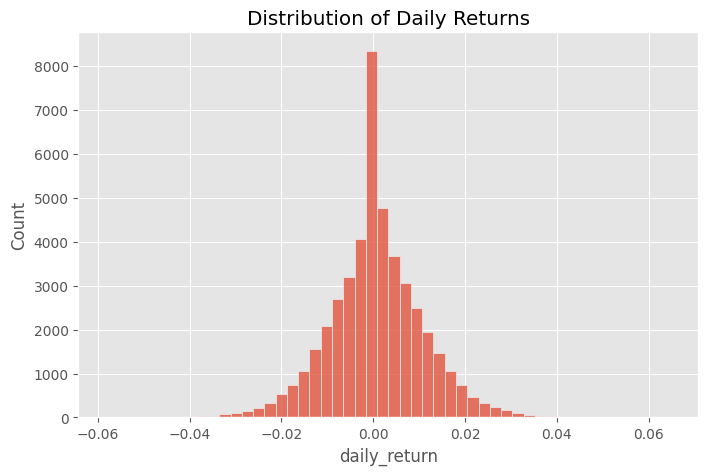

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50
)

plt.title("Distribution of Daily Returns")
plt.show()

## Insight 1

Daily returns are centered around zero, indicating normal market movement with occasional volatility spikes.

In [7]:
nav.columns

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='object')

In [8]:
def cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years) - 1) * 100

In [9]:
cagr_list = []

for code in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == code]

    start_nav = df["nav"].iloc[0]
    end_nav = df["nav"].iloc[-1]

    years = (
        (df["date"].max() -
         df["date"].min()).days
    ) / 365

    cagr_value = cagr(
        start_nav,
        end_nav,
        years
    )

    cagr_list.append(
        [code, cagr_value]
    )

cagr_df = pd.DataFrame(
    cagr_list,
    columns=["amfi_code", "CAGR"]
)

cagr_df.head()

,amfi_code,CAGR
0,100016,2.635246
1,100025,4.455091
2,100033,30.099704
3,101206,23.520489
4,101207,7.933121


In [10]:
cagr_df.sort_values(
    "CAGR",
    ascending=False
).head(10)

,amfi_code,CAGR
25,120505,32.801599
21,119598,32.398084
39,149324,32.262108
36,148569,31.924486
34,148567,30.949920
30,120843,30.883326
2,100033,30.099704
38,149323,29.558105
16,119094,28.192608
19,119551,25.784921


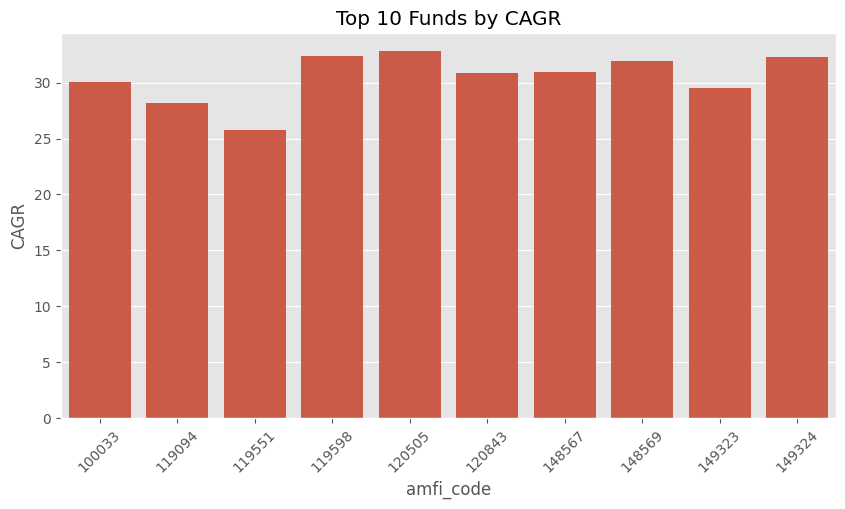

In [11]:
top10 = cagr_df.sort_values(
    "CAGR",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top10,
    x="amfi_code",
    y="CAGR"
)

plt.title("Top 10 Funds by CAGR")
plt.xticks(rotation=45)

plt.show()

## Insight 2

Funds with higher CAGR have generated stronger long-term wealth creation and consistently outperformed lower-ranked funds.

In [12]:
RF = 0.065

In [13]:
sharpe_data = []

for code in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"] == code
    ]

    returns = df[
        "daily_return"
    ].dropna()

    annual_return = (
        returns.mean() * 252
    )

    annual_std = (
        returns.std() * np.sqrt(252)
    )

    sharpe = (
        annual_return - RF
    ) / annual_std

    sharpe_data.append(
        [code, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_data,
    columns=[
        "amfi_code",
        "Sharpe"
    ]
)

sharpe_df.head()

,amfi_code,Sharpe
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [14]:
sharpe_df.sort_values(
    "Sharpe",
    ascending=False
).head(10)

,amfi_code,Sharpe
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


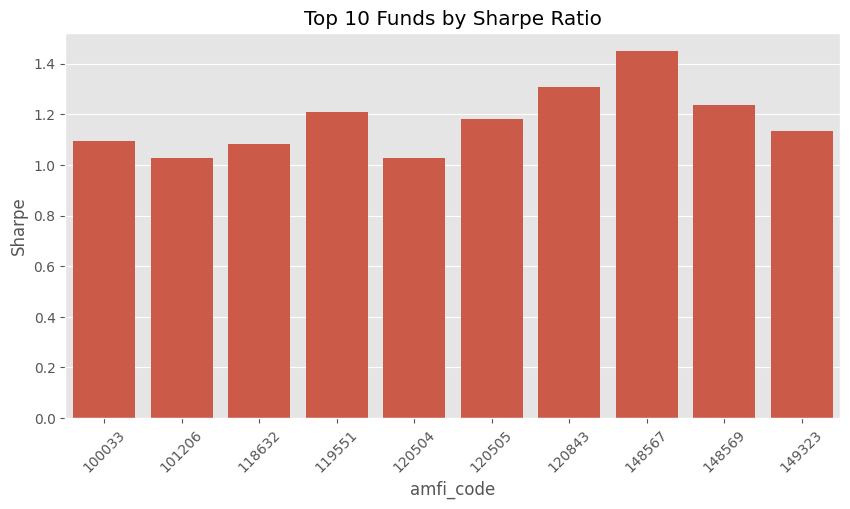

In [15]:
top10_sharpe = sharpe_df.sort_values(
    "Sharpe",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top10_sharpe,
    x="amfi_code",
    y="Sharpe"
)

plt.title(
    "Top 10 Funds by Sharpe Ratio"
)

plt.xticks(rotation=45)

plt.show()

## Insight 3

Funds with higher Sharpe Ratios delivered better returns for each unit of risk taken, making them more attractive on a risk-adjusted basis.

In [16]:
sortino_list = []

for code in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"] == code
    ]

    returns = df[
        "daily_return"
    ].dropna()

    downside = returns[
        returns < 0
    ]

    sortino = (
        (returns.mean() * 252) - RF
    ) / (
        downside.std() * np.sqrt(252)
    )

    sortino_list.append(
        [code, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_list,
    columns=[
        "amfi_code",
        "Sortino"
    ]
)

sortino_df.head()

,amfi_code,Sortino
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [17]:
sortino_df.sort_values(
    "Sortino",
    ascending=False
).head(10)

,amfi_code,Sortino
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


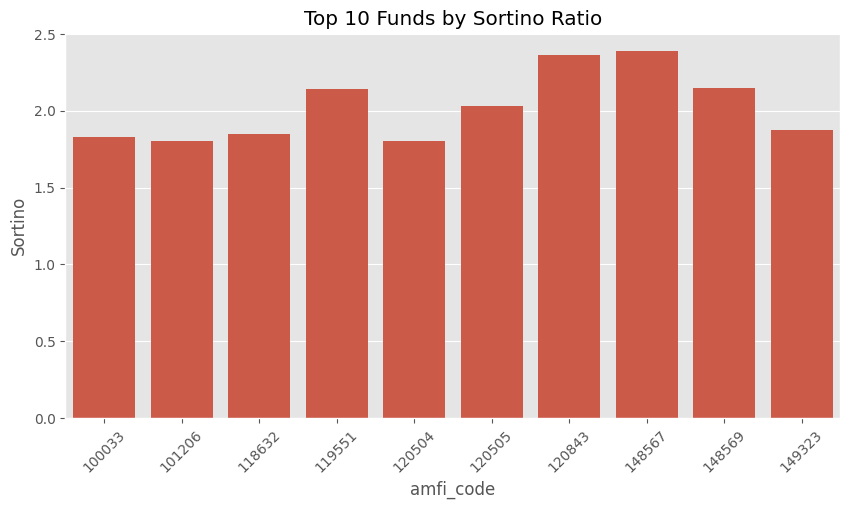

In [18]:
top10_sortino = sortino_df.sort_values(
    "Sortino",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top10_sortino,
    x="amfi_code",
    y="Sortino"
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.xticks(rotation=45)

plt.show()

## Insight 4

Sortino Ratio focuses only on downside risk. Funds with higher Sortino Ratios generated superior returns while minimizing negative-return periods.

In [19]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [20]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")
    ["close_value"]
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [21]:
benchmark["index_name"].unique()

array(['BSE_SMALLCAP', 'CRISIL_GILT', 'CRISIL_LIQUID', 'NIFTY100',
       'NIFTY50', 'NIFTY500', 'NIFTY_MIDCAP150'], dtype=object)

In [22]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY 100"
]

In [23]:
alpha_beta = []

for code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == code
    ]

    merged = pd.merge(
        fund,
        nifty100[
            ["date",
             "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r, p, se = (
        linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )
    )

    alpha = intercept * 252
    beta = slope

    alpha_beta.append(
        [code, alpha, beta]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "Alpha",
        "Beta"
    ]
)

alpha_beta_df.head()

,amfi_code,Alpha,Beta


In [24]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

## Insight 5

Funds with positive Alpha generated returns above what would be expected based on market risk (Beta), indicating superior fund management performance.

In [25]:
benchmark["index_name"].unique()

array(['BSE_SMALLCAP', 'CRISIL_GILT', 'CRISIL_LIQUID', 'NIFTY100',
       'NIFTY50', 'NIFTY500', 'NIFTY_MIDCAP150'], dtype=object)

In [26]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
]

In [27]:
alpha_beta_df.head()

,amfi_code,Alpha,Beta


In [28]:
alpha_beta_df.describe()

,amfi_code,Alpha,Beta
count,0,0,0
unique,0,0,0
top,NaN,NaN,NaN
freq,NaN,NaN,NaN


In [29]:
dd_list = []

for code in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"] == code
    ].copy()

    running_max = df["nav"].cummax()

    drawdown = (
        df["nav"] / running_max
    ) - 1

    max_dd = drawdown.min()

    dd_list.append(
        [code, max_dd]
    )

dd_df = pd.DataFrame(
    dd_list,
    columns=[
        "amfi_code",
        "Max_Drawdown"
    ]
)

dd_df.head()

,amfi_code,Max_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


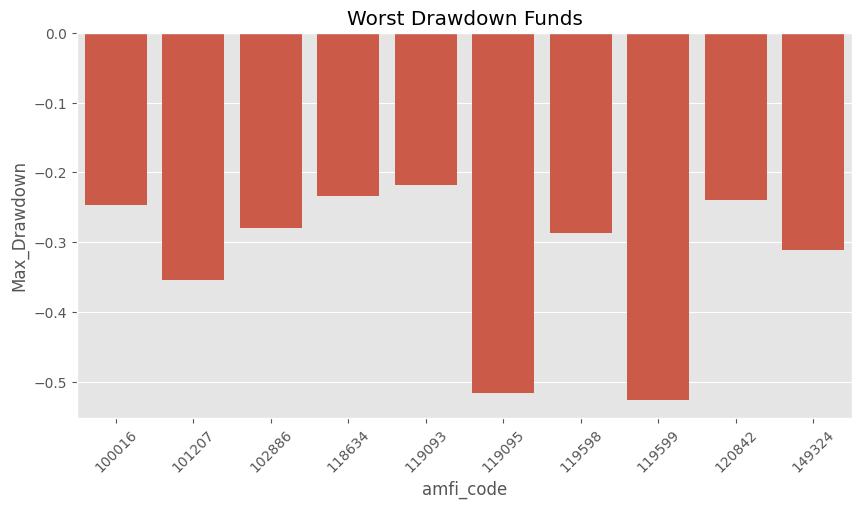

In [30]:
worst_dd = dd_df.sort_values(
    "Max_Drawdown"
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=worst_dd,
    x="amfi_code",
    y="Max_Drawdown"
)

plt.title(
    "Worst Drawdown Funds"
)

plt.xticks(rotation=45)

plt.show()

## Insight 6

Funds with deeper drawdowns experienced larger declines from their historical peaks, indicating higher downside risk.

In [31]:
scorecard = (
    cagr_df
    .merge(sharpe_df)
    .merge(alpha_beta_df)
    .merge(dd_df)
)

scorecard.head()

,amfi_code,CAGR,Sharpe,Alpha,Beta,Max_Drawdown


In [32]:
scorecard["score"] = (

    scorecard["CAGR"]
    .rank(pct=True) * 30

    +

    scorecard["Sharpe"]
    .rank(pct=True) * 25

    +

    scorecard["Alpha"]
    .rank(pct=True) * 20

    +

    scorecard["Max_Drawdown"]
    .rank(
        pct=True,
        ascending=False
    ) * 10

)

In [33]:
scorecard.sort_values(
    "score",
    ascending=False
).head(10)

,amfi_code,CAGR,Sharpe,Alpha,Beta,Max_Drawdown,score


In [34]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

## Insight 7

The composite scorecard combines return, risk-adjusted performance, alpha generation, and downside protection to identify the strongest overall funds.

In [35]:
top5_codes = (
    scorecard
    .sort_values(
        "score",
        ascending=False
    )
    .head(5)
    ["amfi_code"]
    .tolist()
)

top5_codes

[]

C:\Users\anura\AppData\Local\Temp\ipykernel_21512\2059182841.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


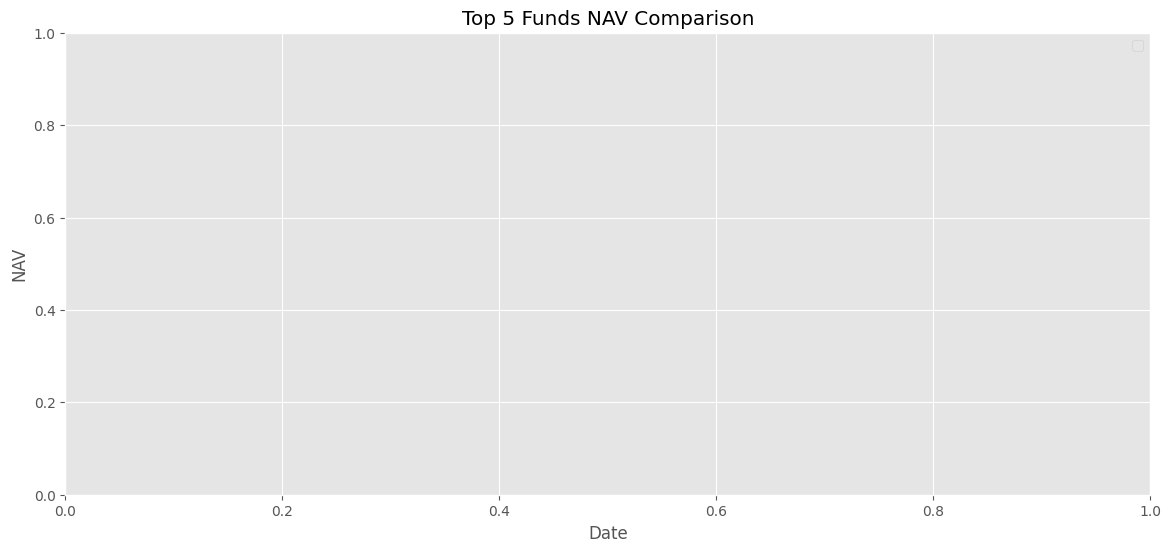

In [36]:
top5_nav = nav[
    nav["amfi_code"].isin(
        top5_codes
    )
]

plt.figure(figsize=(14,6))

for code in top5_codes:

    temp = top5_nav[
        top5_nav["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(code)
    )

plt.legend()

plt.title(
    "Top 5 Funds NAV Comparison"
)

plt.xlabel("Date")
plt.ylabel("NAV")

plt.show()

C:\Users\anura\AppData\Local\Temp\ipykernel_21512\957159147.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


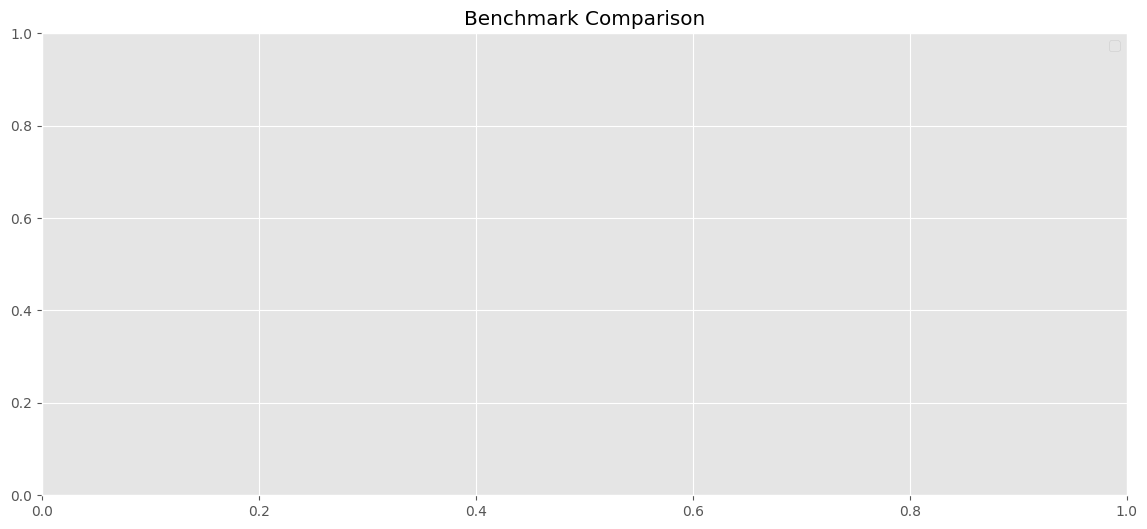

In [37]:
plt.figure(figsize=(14,6))

for code in top5_codes:

    temp = top5_nav[
        top5_nav["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(code)
    )

plt.legend()

plt.title(
    "Benchmark Comparison"
)

plt.savefig(
    "../reports/benchmark_comparison.png"
)

plt.show()

## Insight 8

Top-ranked funds consistently outperformed peers over the analysis period, demonstrating stronger NAV growth and lower downside risk.

In [38]:
import os

print(os.listdir("../reports"))

['alpha_beta.csv', 'aum_growth.png', 'benchmark_comparison.png', 'data_dictionary.md', 'data_quality_report.txt', 'fund_scorecard.csv', 'sip_trend.png']
